задание 23

(a) Является ли каждое MBST минимальным остовным деревом?                                                                                                  
Да, является.

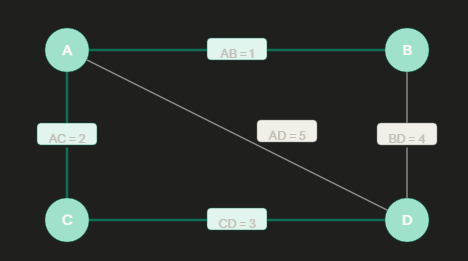

Проверка всех остовных деревьев (3 ребра, без цикла):
                                                                                                                            
{AB, AC, CD}: сумма 6, макс 3 ← MST и MBST                                                                                                               
{AB, AC, BD}: сумма 7, макс 4                                                                                                                            
{AB, CD, BD}: сумма 8, макс 4                                                                                                                            
{AB, CD, AD}: сумма 9, макс 5                                                                                                                            
{AC, CD, BD}: сумма 9, макс 4                                                                                                                            
{AC, CD, AD}: сумма 10, макс 5                                                                                                                           
{AB, AC, AD}: сумма 8, макс 5                                                                                                                            
{AB, BD, AD}: сумма 10, макс 5                                                                                                                           
                                                                                                                                                         
Минимальная сумма и минимальное максимальное ребро достигаются на одном и том же дереве — {AB, AC, CD}. Это иллюстрация того, что при различных           стоимостях MST и MBST совпадают.

(b) Является ли каждое минимальное остовное дерево графа G минимально-
критичным деревом графа G? 
Да, каждое минимальное остовное дерево является минимально-критическим.

Коротко почему:

Если в MST самое большое ребро имеет вес w, то нельзя построить другое остовное дерево, где все рёбра меньше w.

Потому что тогда существовало бы дерево «лучше», и текущее MST не было бы минимальным.

Значит максимальное ребро в MST уже минимально возможное.

Следовательно, любое MST — минимально-критическое дерево.

задание 24 (а)

In [5]:
def check_mst_after_adding_edge(tree_edges, v, w, c):
    # Находим путь от v до w в дереве T (BFS)
    graph = {}
    for u, x, cost in tree_edges:
        graph.setdefault(u, []).append((x, cost))
        graph.setdefault(x, []).append((u, cost))
    
    # BFS для поиска пути
    from collections import deque
    parent = {v: (None, 0)}
    queue = deque([v])
    while queue:
        node = queue.popleft()
        if node == w:
            break
        for neighbor, cost in graph.get(node, []):
            if neighbor not in parent:
                parent[neighbor] = (node, cost)
                queue.append(neighbor)
    
    # Восстанавливаем максимальное ребро на пути
    max_edge = 0
    cur = w
    while parent[cur][0] is not None:
        max_edge = max(max_edge, parent[cur][1])
        cur = parent[cur][0]
    
    # Если c >= max_edge, то T остаётся MST
    if c >= max_edge:
        return "T остаётся минимальным остовным деревом"
    else:
        return "T больше не является MST"

In [6]:
tree = [(1, 2, 3), (2, 3, 4), (3, 4, 2), (2, 5, 5)]
v, w, c = 1, 4, 6
check_mst_after_adding_edge(tree, v, w, c)

'T остаётся минимальным остовным деревом'

In [7]:
v, w, c = 1, 4, 1
check_mst_after_adding_edge(tree, v, w, c)

'T больше не является MST'

задание 24 (b)

In [13]:
from collections import deque

In [14]:
def replace_mst(tree_edges, v, w, c):
    
    graph = {}
    for u, x, cost in tree_edges:
        graph.setdefault(u, []).append((x, cost))
        graph.setdefault(x, []).append((u, cost))
    
    parent = {v: (None, None, 0)}  # (предок, ребро (a,b), стоимость)
    queue = deque([v])
    while queue:
        node = queue.popleft()
        if node == w:
            break
        for neighbor, cost in graph.get(node, []):
            if neighbor not in parent:
                parent[neighbor] = (node, (node, neighbor), cost)
                queue.append(neighbor)
    
    # Ищем самое тяжёлое ребро на пути от v к w
    max_cost = -1
    max_edge = None
    cur = w
    while parent[cur][0] is not None:
        if parent[cur][2] > max_cost:
            max_cost = parent[cur][2]
            max_edge = parent[cur][1]
        cur = parent[cur][0]
    
    # Если новое ребро дешевле — заменяем
    if c < max_cost:
        new_tree = []
        for u, x, cost in tree_edges:
            if (u, x) == max_edge or (x, u) == max_edge:
                continue
            new_tree.append((u, x, cost))
        new_tree.append((v, w, c))
        return new_tree
    else:
        return tree_edges

In [15]:
tree = [(1, 2, 3), (2, 3, 4), (3, 4, 2), (2, 5, 5)]
replace_mst(tree, 1, 4, 1)

[(1, 2, 3), (3, 4, 2), (2, 5, 5), (1, 4, 1)]

задание 25

Да, для любого графа G и любого минимального остовного дерева T графа G существует действительное выполнение алгоритма Крускала, которое выдаёт T.
Доказательство:
Построим действительное упорядочение рёбер графа G следующим образом:

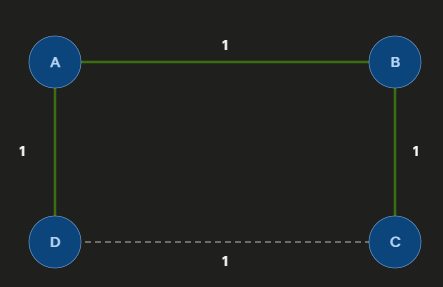

Сортируем все рёбра по возрастанию стоимости.
Среди рёбер с одинаковой стоимостью располагаем сначала те, которые принадлежат T, а затем все остальные.

Такое упорядочение является действительным, поскольку последовательность стоимостей рёбер не убывает.
Покажем, что при таком порядке алгоритм Крускала выдаст именно T.
Случай 1. Алгоритм рассматривает ребро e ∈ T.
Поскольку T — дерево, оно не содержит циклов. Значит, любое подмножество рёбер T также не содержит циклов. Следовательно, ребро e не образует цикл с ранее выбранными рёбрами из T, и алгоритм Крускала добавит e в результат.
Случай 2. Алгоритм рассматривает ребро e ∉ T со стоимостью c.
К этому моменту все рёбра из T со стоимостью строго меньше c уже обработаны и добавлены в результат (по Случаю 1). Также обработаны все рёбра из T со стоимостью ровно c (по правилу упорядочения они идут раньше e).
Рассмотрим цикл, который образуется при добавлении e к T. Утверждаем, что все рёбра этого цикла, кроме e, имеют стоимость ≤ c.
Действительно, если бы в цикле существовало ребро f ∈ T со стоимостью > c, то заменив f на e в T, мы получили бы остовное дерево меньшей стоимости, что противоречит минимальности T.
Значит, к моменту рассмотрения e все остальные рёбра цикла уже добавлены в результат, и концы ребра e соединены. Следовательно, алгоритм Крускала отбросит e.
Вывод. При построенном упорядочении алгоритм Крускала выбирает ровно рёбра множества T. Поскольку T — остовное дерево с |V| − 1 рёбрами, и все они выбираются, результатом работы алгоритма будет именно T